In [54]:
# Voici l'Essai avec les données que j'avais fait initialement avec Gauthier, et là tout fonctionne en gros j'arrive à extraire mes données et les nettoyer 
# +je convertis mes données des quaternions en données d'angles et je fais un plot pour vérifier que les données sont cohérentes.
# puis l'étape suivant avec le but de trouver les évenemnts qui correspons au 9 maximum et 9 mimnium .. 
# mais actuellement je suis bloquée à l'étape convertir les quaternions en angles donc j'ai un peu abandonné cette étape même si avec les data de gauthier ça fonctionnait 




import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_droite.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }




===== FILE: Data_droite.csv =====
K-Push:
     time   force
0  0.000  0.3391
1  0.002  0.3241
2  0.004  0.3271
3  0.006  0.3260
4  0.008  0.2902

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.180603 -0.564087 -0.615723  0.519531
1  0.008  0.180578 -0.564136 -0.615774  0.519518
2  0.016  0.180548 -0.564166 -0.615834  0.519426
3  0.024  0.180547 -0.564194 -0.615922  0.519301
4  0.032  0.180516 -0.564223 -0.616013  0.519178

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.662598  0.119934 -0.083679  0.734497
1  0.008 -0.662614  0.119937 -0.083651  0.734515
2  0.016 -0.662615  0.119937 -0.083620  0.734516
3  0.024 -0.662615  0.119937 -0.083590  0.734517
4  0.032 -0.662616  0.119937 -0.083559  0.734518

Baseline wrist: [0.147, -0.607, -0.628, 0.465]
Baseline shoulder: [-0.659, 0.119, -0.083, 0.738]

Shapes: (20840, 2) (5205, 5) (5205, 5)


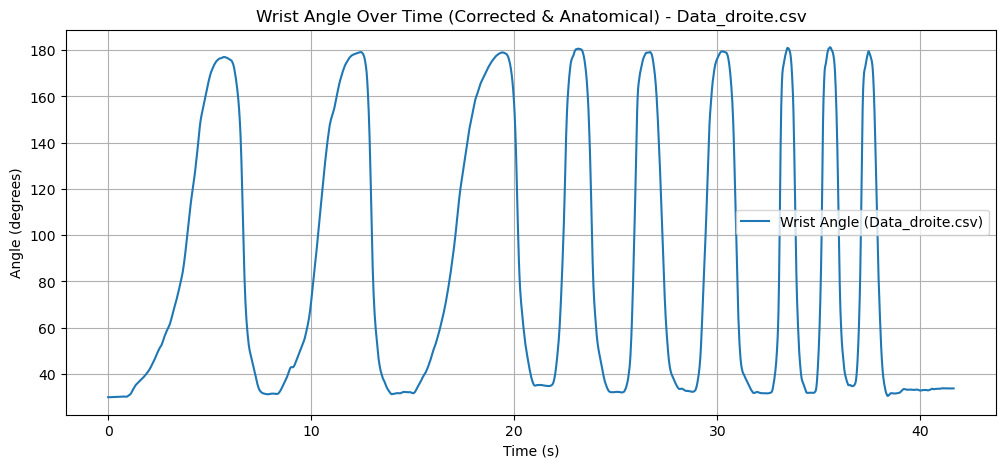

===== FILE: Data_droite.csv =====
Min angle: 29.980334670589514
Max angle: 181.26199870636566


In [55]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_droite.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_droite.csv": 30,
    "Data_GG.csv": 30
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

First 5 rows with filtered angle:
     time      angle  angle_filt
0  0.000  30.000000   30.000042
1  0.008  29.992845   29.994383
2  0.016  29.989396   29.989358
3  0.024  29.984071   29.985518
4  0.032  29.980335   29.983244


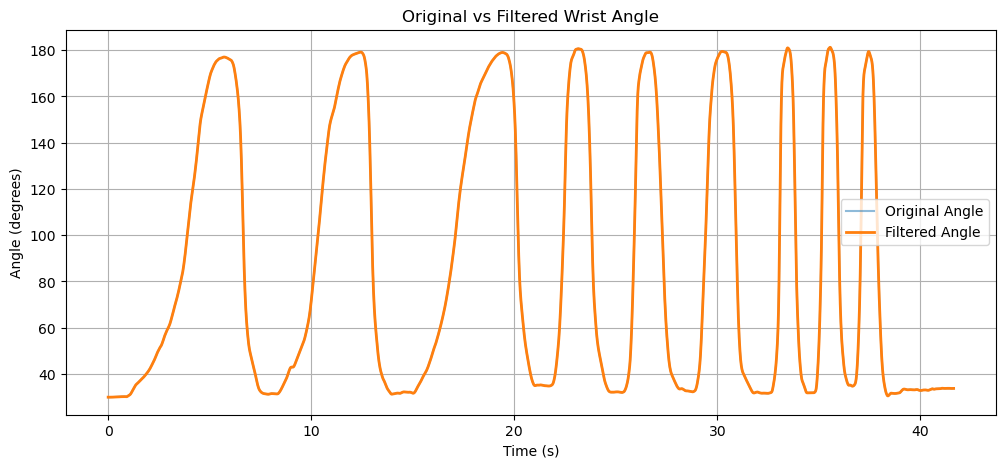

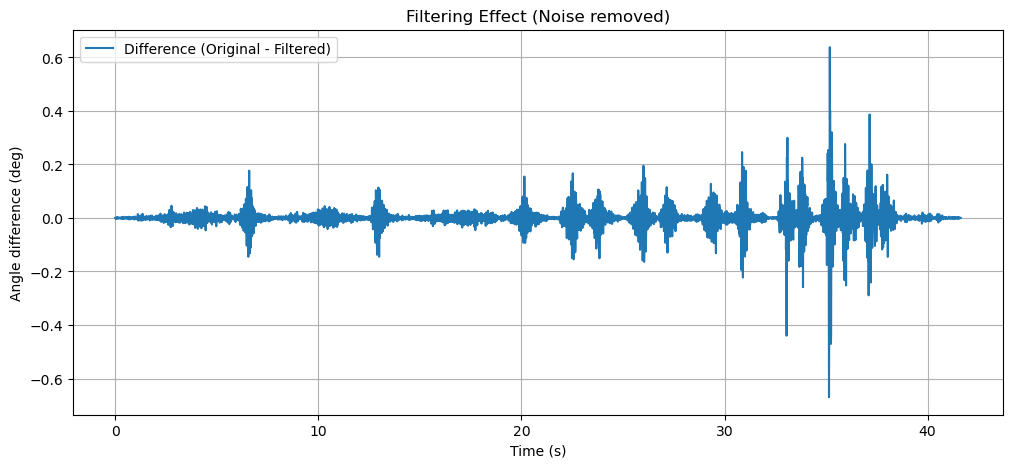

In [56]:
## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()

Extension peaks (max): [ 715 1555 2427 2892 3334 3780 4183 4444 4681]
Extension values: [177.015222   179.15958977 179.00851863 180.6377516  179.17330486
 179.45873258 180.97740318 181.22065221 179.40828618]
Flexion peaks (min): [   5  983 1746 3162 3597 4056 4304 4799 5000]
Flexion values: [29.98269837 31.25356795 31.30177959 32.02873294 32.30595716 31.63336577
 31.85129529 30.54386397 32.88022472]
Number of extension peaks: 9
Number of flexion peaks: 9


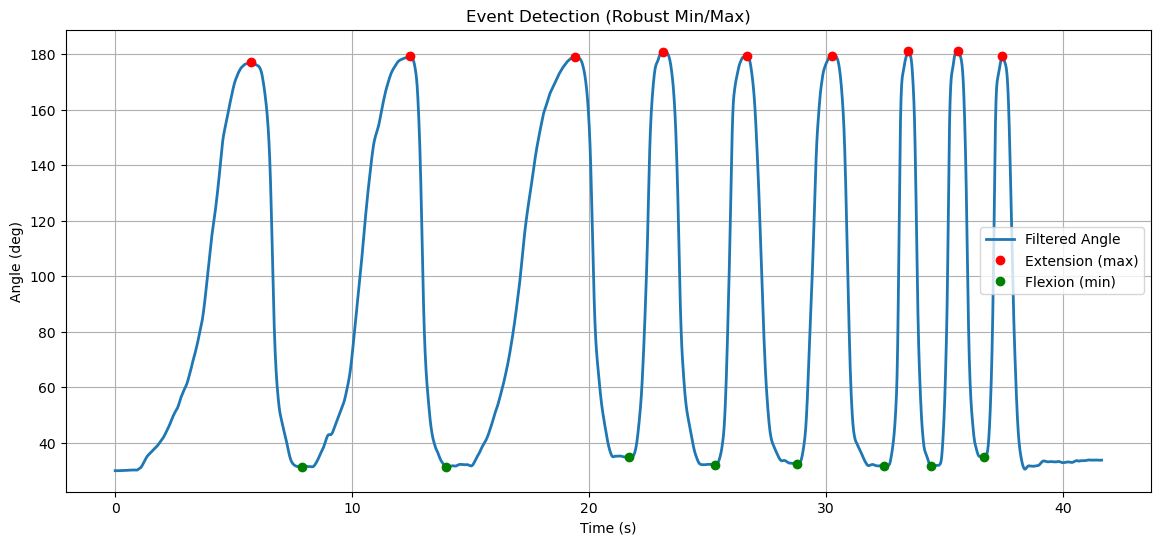

In [57]:
# STEP 4 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()

In [58]:
# ET là je refais le même processus avec les data que j'ai réalisé sur Chahine mercredi dernier
# la seule différence normalement c'est que la fréquence d'échantillonnage est de 250Hz au lieu de 125Hz pour le K move (comparativement avec les data du dessus)
# Et pour le K push la fréquence d'échantillonnage est de 1000Hz au lieu de 250Hz initialement (sur l'essai plus haut) 
# sinon même processis j'extraie les données , je les filtre et les nettoie
# Puis j'essaye de convertir les quaternion x en angle mais là le plot est cata .. c'est en marche d'escalier et aucune solution j'ai plus les belles sinusoïdales comme plus haut. 
# Alors j'ai essayé avec des anciennes data ou j'avais l'ancienne fréquence d'échantillonage mais ça ne marche pas non plus ... 
# j'ai juste esayé de filtrer les données avant comme plus d'acquisition pour éviter le bruit .. mais aucune améliorarion 

import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Ch_G.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }


===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873
1  0.001  0.3454
2  0.002  0.4057
3  0.003  0.4267
4  0.004  0.4324

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.238220  0.542358  0.726257  0.348633
1  0.004  0.238228  0.542376  0.726250  0.348674
2  0.008  0.238227  0.542373  0.726216  0.348764
3  0.012  0.238227  0.542344  0.726188  0.348857
4  0.016  0.238259  0.542317  0.726161  0.348920

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.526794 -0.283691 -0.028687  0.800720
1  0.004 -0.526864 -0.283604 -0.028748  0.800703
2  0.008 -0.526988 -0.283423 -0.028840  0.800676
3  0.012 -0.527083 -0.283302 -0.028870  0.800649
4  0.016 -0.527146 -0.283242 -0.028871  0.800623

Baseline wrist: [0.322, 0.519, 0.689, 0.39]
Baseline shoulder: [-0.515, -0.288, -0.043, 0.806]

Shapes: (47023, 2) (11751, 5) (11751, 5)


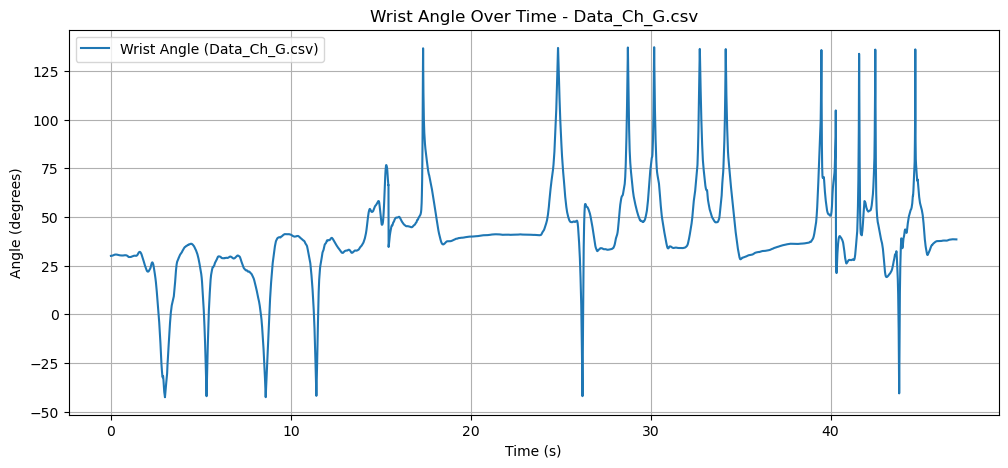

===== FILE: Data_Ch_G.csv =====
Min angle: -42.58489163996251
Max angle: 137.12303350066287


In [59]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE ----------
    angle_rad = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    angle_deg = np.degrees(angle_rad)

    # ---------- STEP 2: CORRECTION 0 → 180 ----------
    angle_deg = (angle_deg + 360) % 360
    angle_deg = np.where(angle_deg > 180, 360 - angle_deg, angle_deg)

    # ---------- STEP 3: ZERO REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # ---------- STEP 4: APPLY BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # ---------- OUTPUT ----------
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Ch_G.csv"]

baseline_angles = {
    "Data_Ch_G.csv": 30
}

angles_results = {}

for file in files:

    df_wrist = results[file]["wrist"]

    manual_baseline = baseline_angles[file]

    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

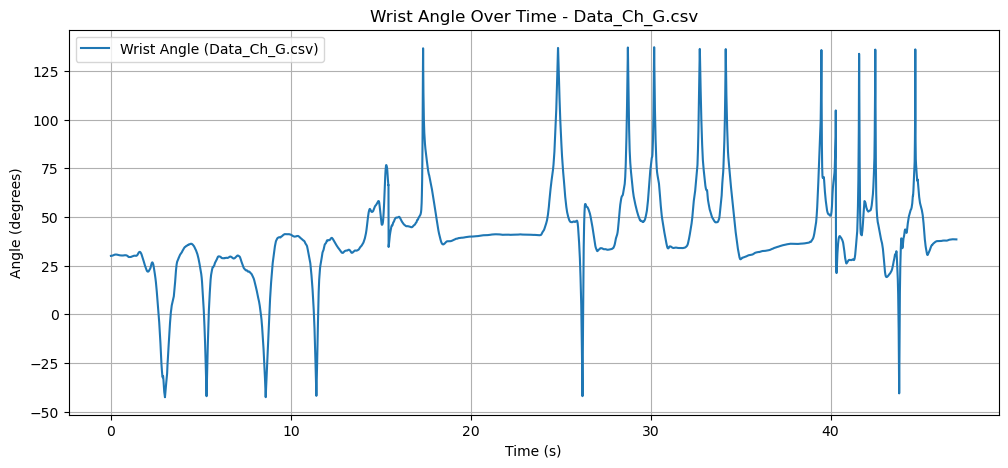

===== FILE: Data_Ch_G.csv =====
Min angle: -42.58489163996251
Max angle: 137.12303350066287


In [60]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_3D(df_quat, baseline_deg):

    def normalize(q):
        return q / np.linalg.norm(q)

    def quat_conjugate(q):
        return np.array([-q[0], -q[1], -q[2], q[3]])

    def quat_multiply(q1, q2):
        x1, y1, z1, w1 = q1
        x2, y2, z2, w2 = q2
        return np.array([
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2,
            w1*w2 - x1*x2 - y1*y2 - z1*z2
        ])

    # baseline quaternion (première frame)
    q0 = normalize([
        df_quat["qx"].iloc[0],
        df_quat["qy"].iloc[0],
        df_quat["qz"].iloc[0],
        df_quat["qw"].iloc[0]
    ])

    q0_inv = quat_conjugate(q0)

    angles = []

    for _, row in df_quat.iterrows():
        q = normalize([row.qx, row.qy, row.qz, row.qw])

        # rotation relative
        q_rel = quat_multiply(q0_inv, q)

        # angle total de rotation
        angle = 2 * np.arccos(np.clip(q_rel[3], -1, 1))

        angles.append(np.degrees(angle))

    angles = np.array(angles)

    # recalage anatomique
    angle_zeroed = angles - angles[0]
    angle_anatomical = angle_zeroed + baseline_deg

    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles



# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Ch_G.csv"]

baseline_angles = {
    "Data_Ch_G.csv": 30
}

angles_results = {}

for file in files:

    df_wrist = results[file]["wrist"]

    manual_baseline = baseline_angles[file]

    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

In [61]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    def quaternion_to_angle_x_corrected(df_quat, baseline_deg):

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- ANGLE BRUT ----------
    angle_rad = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    angle_deg = np.degrees(angle_rad)

    # ---------- CORRECTION : 0 → 180 ----------
    angle_deg = (angle_deg + 360) % 360
    angle_deg = np.where(angle_deg > 180, 360 - angle_deg, angle_deg)

    # ---------- ZERO REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # ---------- AJOUT BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # ---------- DATAFRAME ----------
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles
    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Ch_G.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Ch_G.csv": 30,
    "Data_GG.csv": 30
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

IndentationError: expected an indented block after function definition on line 35 (210232513.py, line 38)

In [ ]:
# ========================================================== Filter files for angle conversion and plotting

# I want to apply filter low  Butterworth  with cutoff frequency of 10 Hz to the angle data before plotting, to reduce noise and get smoother curves.


from scipy.signal import butter, filtfilt
def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ==========================================================
# STEP 2 - FILTER SIGNAL (Wrist quaternion)
# ==========================================================

fs_move = 500  # ⚠️ à adapter (ex: 500 Hz pour K-Move)

filtered_results = {}

for file in results:

    df_wrist = results[file]["wrist"].copy()

    # ---------- FILTRAGE ----------
    df_wrist["qx_filt"] = lowpass_filter(df_wrist["qx"], fs_move)
    df_wrist["qy_filt"] = lowpass_filter(df_wrist["qy"], fs_move)
    df_wrist["qz_filt"] = lowpass_filter(df_wrist["qz"], fs_move)
    df_wrist["qw_filt"] = lowpass_filter(df_wrist["qw"], fs_move)

    # ---------- STOCKAGE ----------
    filtered_results[file] = df_wrist

    # ---------- CHECK ----------
    print(f"\n===== FILTERED: {file} =====")
    print(df_wrist[["qx","qx_filt"]].head())






===== FILTERED: Data_Ch_G.csv =====
         qx   qx_filt
0  0.238220  0.238164
1  0.238228  0.238163
2  0.238227  0.238162
3  0.238227  0.238162
4  0.238259  0.238162



===== FILE: Data_Ch_G.csv =====
→ using FILTERED data


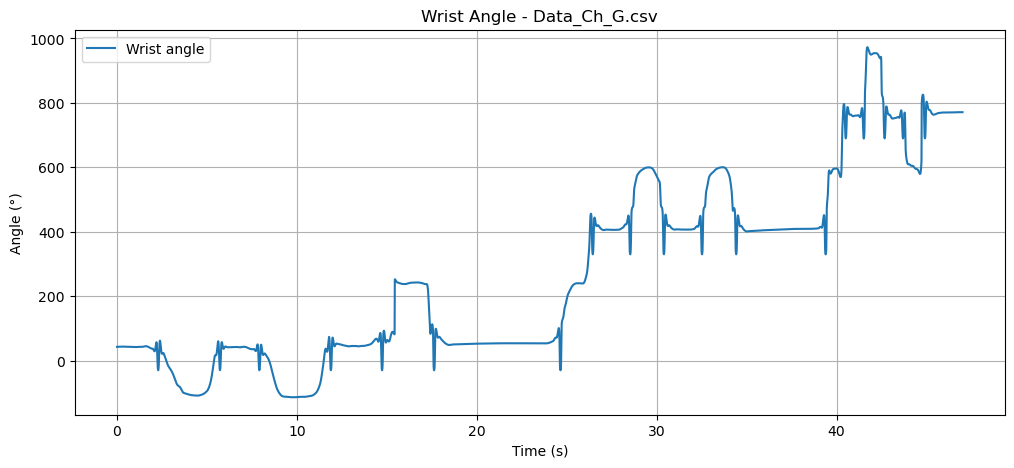

Min: -113.79190832663251
Max: 972.8537938655514


In [ ]:
## STEP 2 - CONVERT QUATERNION TO ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: QUATERNION → ANGLE X (ROLL)
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):

    # 🔥 Utilise les données filtrées SI elles existent
    if "qx_filt" in df_quat.columns:
        qx = df_quat["qx_filt"].values
        qy = df_quat["qy_filt"].values
        qz = df_quat["qz_filt"].values
        qw = df_quat["qw_filt"].values
    else:
        qx = df_quat["qx"].values
        qy = df_quat["qy"].values
        qz = df_quat["qz"].values
        qw = df_quat["qw"].values

    # ---------- CALCUL ANGLE ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- UNWRAP (corrige les sauts 180°) ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- DEGRES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- RELATIF ----------
    angle_relative = angle_deg - baseline_deg

    # ---------- DATAFRAME ----------
    df_angles = df_quat[["time"]].copy()
    df_angles["angle_x"] = angle_deg
    df_angles["angle_relative"] = angle_relative

    return df_angles


# ==========================================================
# PARAMÈTRES (à adapter)
# ==========================================================
baseline_angles = {
    "Data_Ch_G.csv": 30  # 👉 à ajuster selon ton cas réel
}


# ==========================================================
# PROCESSING
# ==========================================================
angles_results = {}

for file in results:

    print(f"\n===== FILE: {file} =====")

    # 🔥 récupère filtré si dispo sinon brut
    if "filtered_results" in globals() and file in filtered_results:
        df_wrist = filtered_results[file]
        print("→ using FILTERED data")
    else:
        df_wrist = results[file]["wrist"]
        print("→ using RAW data")

    # ---------- baseline ----------
    baseline_deg = baseline_angles.get(file, 30)

    # ---------- calcul ----------
    df_angles = quaternion_to_angle_x_corrected(df_wrist, baseline_deg)

    # ---------- stockage ----------
    angles_results[file] = df_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_angles["time"], df_angles["angle_relative"], label="Wrist angle")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Angle - {file}")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---------- CHECK ----------
    print("Min:", df_angles["angle_relative"].min())
    print("Max:", df_angles["angle_relative"].max())

In [ ]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_wrist["qx_filt"]
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Ch_G.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Ch_G.csv": 30,
    "Data_GG.csv": 30
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

KeyError: 'qx_filt'

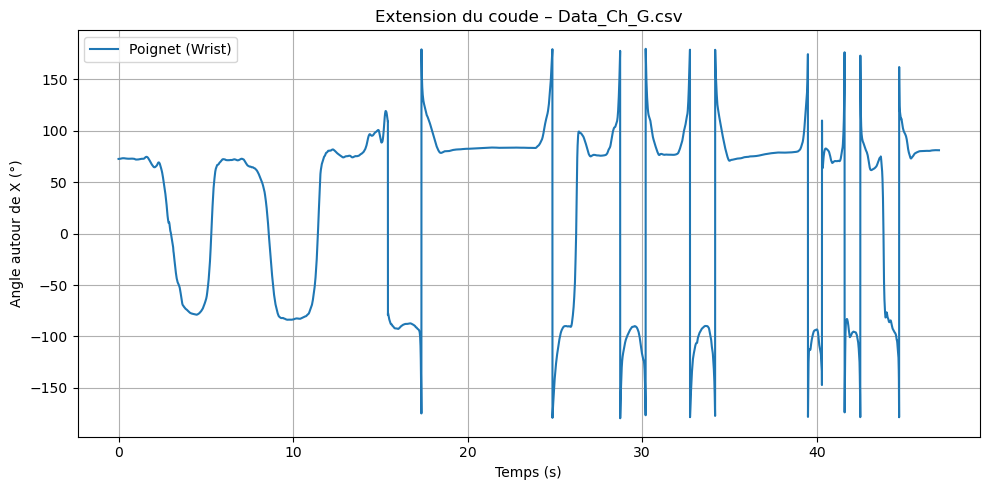


===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873
1  0.001  0.3454
2  0.002  0.4057
3  0.003  0.4267
4  0.004  0.4324

Wrist:
     time        qx        qy        qz        qw  angle_x_deg
0  0.000  0.238220  0.542358  0.726257  0.348633    72.640091
1  0.004  0.238228  0.542376  0.726250  0.348674    72.643249
2  0.008  0.238227  0.542373  0.726216  0.348764    72.642894
3  0.012  0.238227  0.542344  0.726188  0.348857    72.639064
4  0.016  0.238259  0.542317  0.726161  0.348920    72.637126

Shoulder:
     time        qx        qy        qz        qw  angle_x_deg
0  0.000 -0.526794 -0.283691 -0.028687  0.800720   -71.053700
1  0.004 -0.526864 -0.283604 -0.028748  0.800703   -71.057987
2  0.008 -0.526988 -0.283423 -0.028840  0.800676   -71.064236
3  0.012 -0.527083 -0.283302 -0.028870  0.800649   -71.070447
4  0.016 -0.527146 -0.283242 -0.028871  0.800623   -71.076194

Baseline wrist: [0.322, 0.519, 0.689, 0.39]
Baseline shoulder: [-0.515, -0.288, -0.043, 0.

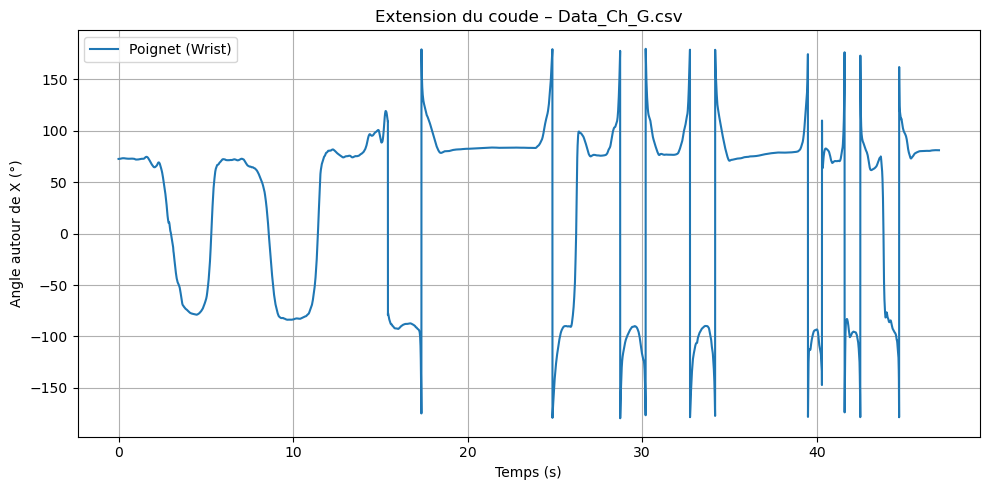

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Ch_G.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]

            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- STEP 6: EXTRACT SENSORS ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)
    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- STEP 7: CONVERT QUATERNIONS → ANGLES (ROLL AROUND X) ----------
    def quaternion_to_roll_deg(df):
        qx, qy, qz, qw = df["qx"], df["qy"], df["qz"], df["qw"]
        roll_rad = np.arctan2(2 * (qw * qx + qy * qz),
                              1 - 2 * (qx**2 + qy**2))
        roll_deg = np.degrees(roll_rad)
        return roll_deg

    df_wrist["angle_x_deg"] = quaternion_to_roll_deg(df_wrist)
    df_shoulder["angle_x_deg"] = quaternion_to_roll_deg(df_shoulder)

    # ---------- STEP 8: PLOT ----------
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(df_wrist["time"], df_wrist["angle_x_deg"], label="Poignet (Wrist)")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle autour de X (°)")
    plt.title(f"Extension du coude – {filename}")       
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()  

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)


    return df_push, df_wrist, df_shoulder, baseline

# ==========================================================
# MAIN
# ==========================================================
files = ["Data_Ch_G.csv"]

for f in files:
    process_file(f)


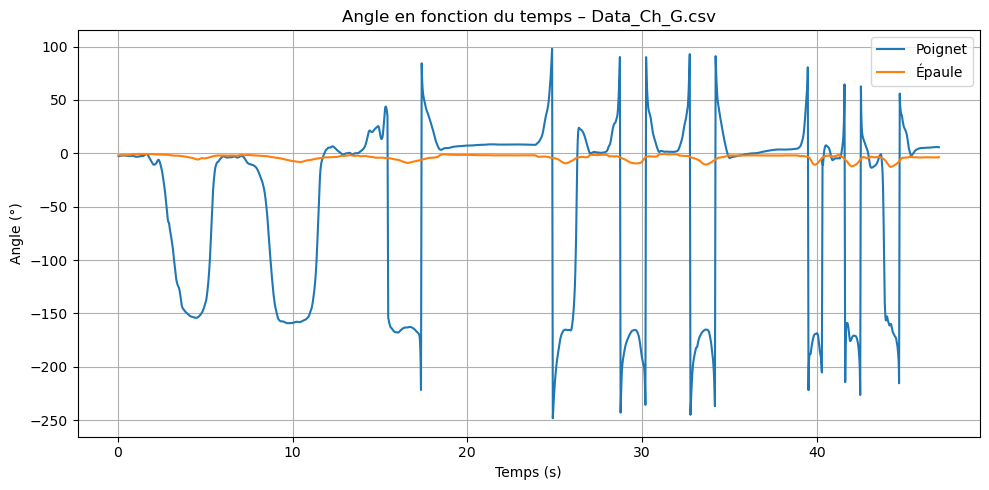

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    return lines


# ==========================================================
# FUNCTION: PROCESS FILE
# ==========================================================
def process_file(filename):

    # ---------- LOAD ----------
    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None
    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- CLEAN PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)
    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]

            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)
    move_data_lines = move_lines[header_idx_move + 1:]

    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- QUATERNION → ANGLE (avec baseline) ----------
    def quaternion_to_roll_deg_corrected(df, baseline_q):
        qx, qy, qz, qw = df["qx"], df["qy"], df["qz"], df["qw"]

        roll_rad = np.arctan2(
            2 * (qw * qx + qy * qz),
            1 - 2 * (qx**2 + qy**2)
        )
        roll_deg = np.degrees(roll_rad)

        # baseline
        qx0, qy0, qz0, qw0 = baseline_q
        baseline_rad = np.arctan2(
            2 * (qw0 * qx0 + qy0 * qz0),
            1 - 2 * (qx0**2 + qy0**2)
        )
        baseline_deg = np.degrees(baseline_rad)

        return roll_deg - baseline_deg

    df_wrist["angle_x_deg"] = quaternion_to_roll_deg_corrected(df_wrist, baseline["wrist"])
    df_shoulder["angle_x_deg"] = quaternion_to_roll_deg_corrected(df_shoulder, baseline["shoulder"])

    # ---------- SMOOTHING ----------
    df_wrist["angle_x_deg"] = df_wrist["angle_x_deg"].rolling(10).mean()
    df_shoulder["angle_x_deg"] = df_shoulder["angle_x_deg"].rolling(10).mean()

    # ---------- RESET TIME ----------
    df_wrist["time"] = df_wrist["time"] - df_wrist["time"].iloc[0]
    df_shoulder["time"] = df_shoulder["time"] - df_shoulder["time"].iloc[0]

    # ---------- PLOT ----------
    plt.figure(figsize=(10, 5))
    plt.plot(df_wrist["time"], df_wrist["angle_x_deg"], label="Poignet")
    plt.plot(df_shoulder["time"], df_shoulder["angle_x_deg"], label="Épaule")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Angle en fonction du temps – {filename}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return df_push, df_wrist, df_shoulder


# ==========================================================
# MAIN
# ==========================================================
files = ["Data_Ch_G.csv"]

for f in files:
    process_file(f)

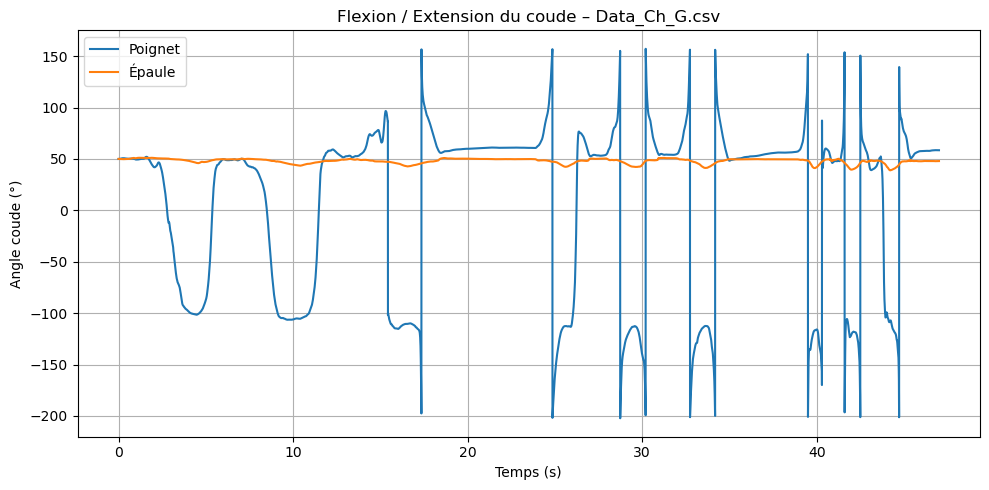


Min / Max wrist : -202.260250399354 157.12303350066293


In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    return lines


# ==========================================================
# FUNCTION: PROCESS FILE
# ==========================================================
def process_file(filename, offset_deg=50):

    # ---------- LOAD ----------
    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None
    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]

    # ---------- FIND HEADER ----------
    header_idx = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)
    move_data_lines = move_lines[header_idx + 1:]

    # ---------- PARSE ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- EXTRACT ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ==========================================================
    # QUATERNION → ANGLE
    # ==========================================================
    def quaternion_to_roll_deg(df):
        qx, qy, qz, qw = df["qx"], df["qy"], df["qz"], df["qw"]
        roll_rad = np.arctan2(
            2 * (qw * qx + qy * qz),
            1 - 2 * (qx**2 + qy**2)
        )
        return np.degrees(roll_rad)

    # ==========================================================
    # CALIBRATION (clé du problème)
    # ==========================================================
    def calibrate_angle(angle_series, offset_deg):
        angle0 = angle_series.iloc[0]   # angle initial
        angle_corr = angle_series - angle0  # recentrage
        angle_corr = angle_corr + offset_deg  # physiologie
        return angle_corr

    # ---------- COMPUTE ----------
    df_wrist["angle_x_deg"] = quaternion_to_roll_deg(df_wrist)
    df_shoulder["angle_x_deg"] = quaternion_to_roll_deg(df_shoulder)

    # ---------- CALIBRATION ----------
    df_wrist["angle_x_deg"] = calibrate_angle(df_wrist["angle_x_deg"], offset_deg)
    df_shoulder["angle_x_deg"] = calibrate_angle(df_shoulder["angle_x_deg"], offset_deg)

    # ==========================================================
    # PLOT
    # ==========================================================
    plt.figure(figsize=(10, 5))

    plt.plot(df_wrist["time"], df_wrist["angle_x_deg"], label="Poignet")
    plt.plot(df_shoulder["time"], df_shoulder["angle_x_deg"], label="Épaule")

    plt.xlabel("Temps (s)")
    plt.ylabel("Angle coude (°)")
    plt.title(f"Flexion / Extension du coude – {filename}")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- DEBUG ----------
    print("\nMin / Max wrist :", df_wrist["angle_x_deg"].min(), df_wrist["angle_x_deg"].max())

    return df_wrist, df_shoulder


# ==========================================================
# MAIN
# ==========================================================
files = ["Data_Ch_G.csv"]

for f in files:
    process_file(f, offset_deg=50)

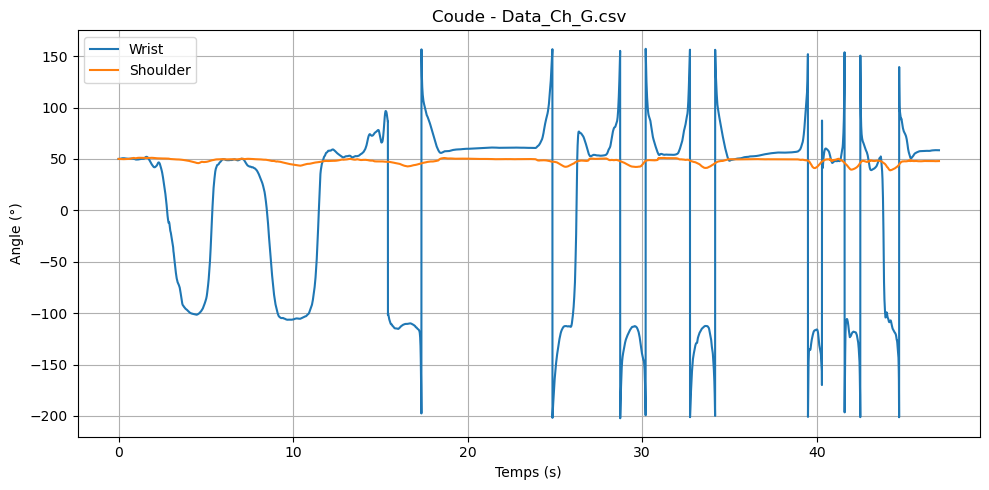


Min/Max Wrist: -202.260250399354 157.12303350066293


In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt

# ==========================================================
# LOAD DATA
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename, offset_deg=50):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None
    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]

    # ---------- HEADER ----------
    header_idx = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)
    move_data_lines = move_lines[header_idx + 1:]

    # ---------- PARSE ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.dropna(axis=1, how="all")
    df_move = df_move.apply(pd.to_numeric, errors="coerce")
    df_move = df_move.ffill().bfill()

    # ---------- EXTRACT ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ==========================================================
    # QUATERNION → ANGLE
    # ==========================================================
    def quaternion_to_roll_deg(df):
        qx, qy, qz, qw = df["qx"], df["qy"], df["qz"], df["qw"]
        roll_rad = np.arctan2(
            2 * (qw * qx + qy * qz),
            1 - 2 * (qx**2 + qy**2)
        )
        return np.degrees(roll_rad)

    # ==========================================================
    # CALIBRATION PROPRE
    # ==========================================================
    def calibrate(angle_series, offset):
        return angle_series - angle_series.iloc[0] + offset

    # ---------- APPLY ----------
    df_wrist["angle_x_deg"] = quaternion_to_roll_deg(df_wrist)
    df_shoulder["angle_x_deg"] = quaternion_to_roll_deg(df_shoulder)

    df_wrist["angle_x_deg"] = calibrate(df_wrist["angle_x_deg"], offset_deg)
    df_shoulder["angle_x_deg"] = calibrate(df_shoulder["angle_x_deg"], offset_deg)

    # ==========================================================
    # PLOT
    # ==========================================================
    plt.figure(figsize=(10,5))
    plt.plot(df_wrist["time"], df_wrist["angle_x_deg"], label="Wrist")
    plt.plot(df_shoulder["time"], df_shoulder["angle_x_deg"], label="Shoulder")

    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Coude - {filename}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    print("\nMin/Max Wrist:", df_wrist["angle_x_deg"].min(), df_wrist["angle_x_deg"].max())

    return df_wrist, df_shoulder


# ==========================================================
# MAIN
# ==========================================================
files = ["Data_Ch_G.csv"]

for f in files:
    process_file(f)

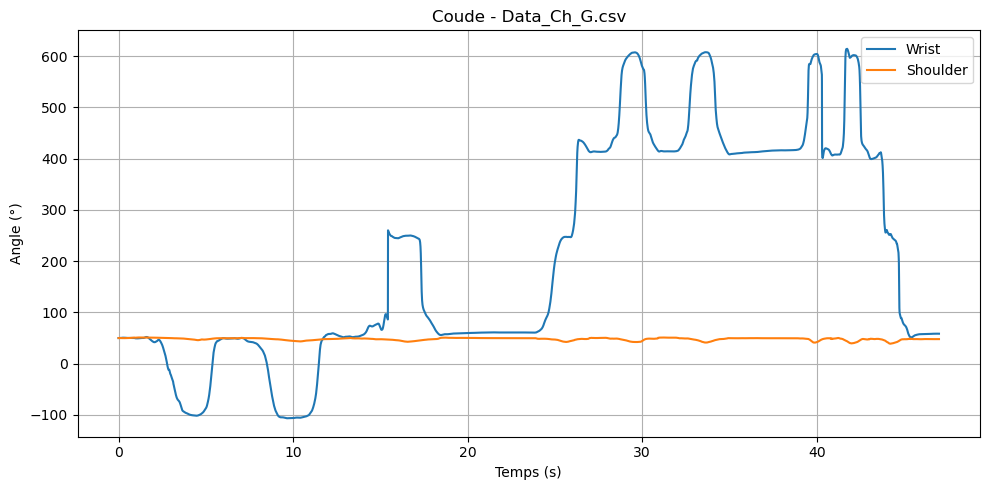


Min/Max Wrist: -106.44959110207208 614.1810506238396


In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt

# ==========================================================
# LOAD DATA
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename, offset_deg=50):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None
    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]

    # ---------- HEADER ----------
    header_idx = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)
    move_data_lines = move_lines[header_idx + 1:]

    # ---------- PARSE ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.dropna(axis=1, how="all")
    df_move = df_move.apply(pd.to_numeric, errors="coerce")
    df_move = df_move.ffill().bfill()

    # ---------- EXTRACT ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ==========================================================
    # QUATERNION → ANGLE
    # ==========================================================
    def quaternion_to_roll_deg(df):
        qx, qy, qz, qw = df["qx"], df["qy"], df["qz"], df["qw"]
        roll_rad = np.arctan2(
            2 * (qw * qx + qy * qz),
            1 - 2 * (qx**2 + qy**2)
        )
        return np.degrees(roll_rad)

    # ==========================================================
    # CALIBRATION AVEC UNWRAP (corrige ton problème)
    # ==========================================================
    
    def calibrate(angle_series, offset):
         angle_unwrapped = np.degrees(np.unwrap(np.radians(angle_series)))
         angle_unwrapped = pd.Series(angle_unwrapped, index=angle_series.index)
         angle0 = angle_unwrapped[0]
         return angle_unwrapped - angle0 + offset

    # ---------- CALCUL ----------
    df_wrist["angle_x_deg"] = quaternion_to_roll_deg(df_wrist)
    df_shoulder["angle_x_deg"] = quaternion_to_roll_deg(df_shoulder)

    # ---------- CALIBRATION ----------
    df_wrist["angle_x_deg"] = calibrate(df_wrist["angle_x_deg"], offset_deg)
    df_shoulder["angle_x_deg"] = calibrate(df_shoulder["angle_x_deg"], offset_deg)

    # ==========================================================
    # PLOT
    # ==========================================================
    plt.figure(figsize=(10,5))
    plt.plot(df_wrist["time"], df_wrist["angle_x_deg"], label="Wrist")
    plt.plot(df_shoulder["time"], df_shoulder["angle_x_deg"], label="Shoulder")

    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Coude - {filename}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    print("\nMin/Max Wrist:", df_wrist["angle_x_deg"].min(), df_wrist["angle_x_deg"].max())

    return df_wrist, df_shoulder


# ==========================================================
# MAIN
# ==========================================================
files = ["Data_Ch_G.csv"]

for f in files:
    process_file(f)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# MAIN FUNCTION (AXE Y UNIQUEMENT)
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    # ---------- BASELINE ----------
    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        # ---------- CALIBRATION ----------
        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        # ---------- ANGLE Y (FORMULE STABLE) ----------
        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.array(angles)

    # ---------- UNWRAP ----------
    angles = np.unwrap(angles)

    # ---------- DEGRE ----------
    angle_deg = np.degrees(angles)

    # ---------- ZERO ----------
    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- ANATOMICAL ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # ---------- OUTPUT ----------
    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df


# ==========================================================
# PROCESSING + PLOT
# ==========================================================
angles_results = {}

for file in results:

    print(f"\n===== FILE: {file} =====")

    df_wrist = results[file]["wrist"]
    baseline_quat = results[file]["baseline"]["wrist"]

    if len(baseline_quat) != 4:
        print("⚠️ Baseline quaternion manquant → skip")
        continue

    baseline_deg = 30

    # ---------- CALCUL ----------
    df_angles = quaternion_to_angle_y_calibrated(
        df_wrist,
        baseline_quat,
        baseline_deg
    )

    angles_results[file] = df_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_angles["time"], df_angles["angle"], label="Wrist angle (Y)")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Flexion / Extension - {file}")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---------- CHECK ----------
    print("Min:", df_angles["angle"].min())
    print("Max:", df_angles["angle"].max())

NameError: name 'results' is not defined

In [ ]:


import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Ch_D.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }


===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)


In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# BUILD RESULTS
# ==========================================================
files = ["Data_CH_D.csv"]  # adapte ici

results = {}

for file in files:
    try:
        df_push, df_wrist, df_shoulder, baseline = process_file(file)

        results[file] = {
            "push": df_push,
            "wrist": df_wrist,
            "shoulder": df_shoulder,
            "baseline": baseline
        }

        print(f"Loaded: {file}")

    except FileNotFoundError as e:
        print(f"[WARNING] {e}")

Loaded: Data_CH_D.csv


In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# BUILD RESULTS
# ==========================================================
files = ["Data_CH_D.csv"]  # adapte ici

results = {}

for file in files:
    try:
        df_push, df_wrist, df_shoulder, baseline = process_file(file)

        results[file] = {
            "push": df_push,
            "wrist": df_wrist,
            "shoulder": df_shoulder,
            "baseline": baseline
        }

        print(f"Loaded: {file}")

    except FileNotFoundError as e:
        print(f"[WARNING] {e}")

Loaded: Data_CH_D.csv

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# MAIN FUNCTION (AXE Y UNIQUEMENT)
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    # ---------- BASELINE ----------
    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        # ---------- CALIBRATION ----------
        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        # ---------- ANGLE Y (FORMULE STABLE) ----------
        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.array(angles)

    # ---------- UNWRAP ----------
    angles = np.unwrap(angles)

    # ---------- DEGRE ----------
    angle_deg = np.degrees(angles)

    # ---------- ZERO ----------
    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- ANATOMICAL ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # ---------- OUTPUT ----------
    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df


# ==========================================================
# PROCESSING + PLOT
# ==========================================================
angles_results = {}

for file in results:

    print(f"\n===== FILE: {file} =====")

    df_wrist = results[file]["wrist"]
    baseline_quat = results[file]["baseline"]["wrist"]

    if len(baseline_quat) != 4:
        print("⚠️ Baseline quaternion manquant → skip")
        continue

    baseline_deg = 30

    # ---------- CALCUL ----------
    df_angles = quaternion_to_angle_y_calibrated(
        df_wrist,
        baseline_quat,
        baseline_deg
    )

    angles_results[file] = df_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_angles["time"], df_angles["angle"], label="Wrist angle (Y)")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Flexion / Extension - {file}")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---------- CHECK ----------
    print("Min:", df_angles["angle"].min())
    print("Max:", df_angles["angle"].max())



Loaded: Data_CH_D.csv


NameError: name 'Data_CH_D' is not defined